###### Content under Creative Commons Attribution license CC-BY 4.0, code under BSD 3-Clause License © 2018  by D. Koehn, T. Meier and R. Hartmann, notebook style sheet by L.A. Barba, N.C. Clementi

# Vibroseismic and Correlation Filters

As a first example of the application of AKF and KKF in geophysics, we analyse the concept of the vibroseismic method using synthetic time series and field data.

## Fundamentals of Vibroseismic Surveying

As an alternative to explosive seismic methods and impact sources, such as hammers or falling weights, **vibroseismic surveying** was introduced in the 1950s in the context of oil exploration. 

Vibroseismic vehicles serve as the seismic source. These consist of a combination of a large mass and a hydraulically operated vibrating plate.

<img src="images/vibro_web.jpg" style="width: 800px;"/>

The vibroseis source feeds a frequency-modulated sweep signal $x(t)$ in the frequency range $f\in[f_1,f_2]$:

\begin{equation}
x(t)=
\begin{cases}
\sin\left(2\pi\left(f_{1}+\frac{f_{2}-f_{1}}{T}t\right)t\right)&:t\in[0,T]\\
0&:\text{ otherwise}
\end{cases}
\notag
\end{equation}

with period $T$ into the ground. As an example, we shall calculate a sweep signal with the following properties:

$f_1 = 10\; Hz$, $f_2 = 100\; Hz$, $T = 10\; s$

In [1]:
# Import Python libraries 
# -----------------------
import numpy                      # Library NumPy
from gsv.gsv_func import *        # Library "Geophysikalische Signalverarbeitung"

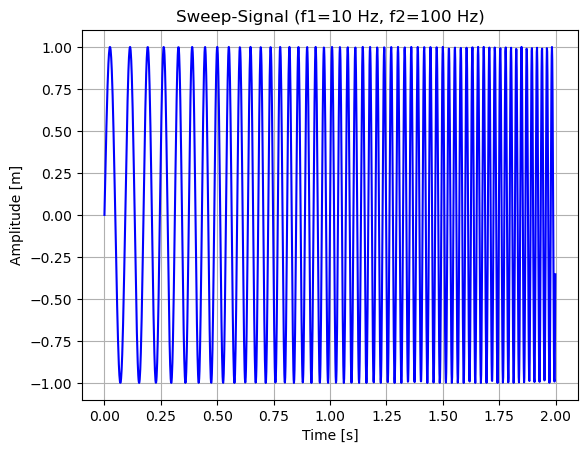

In [2]:
# Define Sweep
# ------------
f1 = 10.0                             # minimum sweep frequency f1
f2 = 100.0                            # maximum sweep frequency f2
T = 10.0                              # sweep length [s]
time, sweep = create_sweep(f1,f2,T)   # Create sweep signal

# Plot sweep signal up to 2 s
nt_max = (int)(2.0 / (time[1]-time[0]))
draw_func1(time[0:nt_max],sweep[0:nt_max],'Sweep-Signal (f1=10 Hz, f2=100 Hz)', 'Time [s]', 'Amplitude [m]')

The spectrum of the AKF then takes the form:

\begin{equation}
\mathfrak{F}\{\rho_{x,x}(\tau)\}=X(f)^{\ast} X(f)\approx
\begin{cases}
1&: f \in [f_{1}, f_{2}] \\
0&: \text{otherwise}
\end{cases}
\notag
\end{equation}

The AKF of the sweep can be approximated as follows

\begin{equation}
\rho_{x,x}(\tau)\approx\frac{\sin(\pi(f_{2}-f_{1})\tau)}{\pi(f_{2}-f_{1})\tau}\cdot\cos(2\pi(\frac{f_{1}+f_{2}}{2})\tau)
\notag
\end{equation}

Here, the first term represents amplitude modulation and the second term represents an oscillation with the carrier frequency $(f_{1}+f_{2})/2$.

D:\Lectures\Geophysikalische_Signalanalyse\Digital-Signal-Processing-in-Geophysics-main\Lectures\Chapter_08_Correlation\gsv\gsv_func.py:302: RuntimeWarning: invalid value encountered in divide
  AKF_an = (np.sin(k) / k) * np.cos(k1)


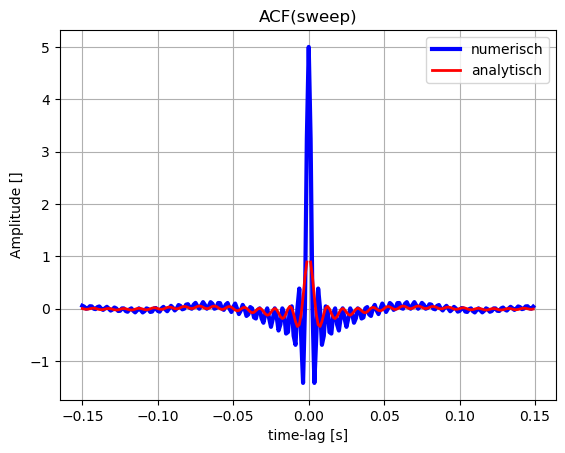

In [3]:
# AKF of sweep signal
AKF_sweep = np.correlate(sweep, sweep, mode='same')

# Multiply with KKF_sweep with dt to get correct amplitudes
dt = time[1] - time[0]
AKF_sweep = AKF_sweep * dt

# Compute time-lags
nt = (int)(len(time))
lags = np.arange(-nt/2,nt/2,1) * dt # time-lags

# Plot AKF of sweep up to +- 0.15 s
nth = (int)(len(time) / 2)
nt_AKF = (int)(0.15 / dt)
nt1 = nth - nt_AKF
nt2 = nth + nt_AKF
comp_AKF_sweep(lags[nt1:nt2],AKF_sweep[nt1:nt2],f1,f2,T,'ACF(sweep)','time-lag [s]', 'Amplitude []')

From the uncertainty principle 

\begin{equation*}
2\pi = \frac{\Delta \omega\Delta T}{2} 
\end{equation*}

it follows that the effective length of $\rho_{x,x}(t)$ is:

\begin{equation*}
4\pi=(\omega_{2}-\omega_{1})\Delta T
\end{equation*}

or 

\begin{equation*}
\Delta T=\frac{2}{f_{2}-f_{1}}<<T
\end{equation*}

This means that a broadband sweep increases the temporal resolution of the AKF. The temporal resolution of the AKF of the sweep $\rho_{x,x}$ is significantly higher than the length $T$ of the sweep itself.

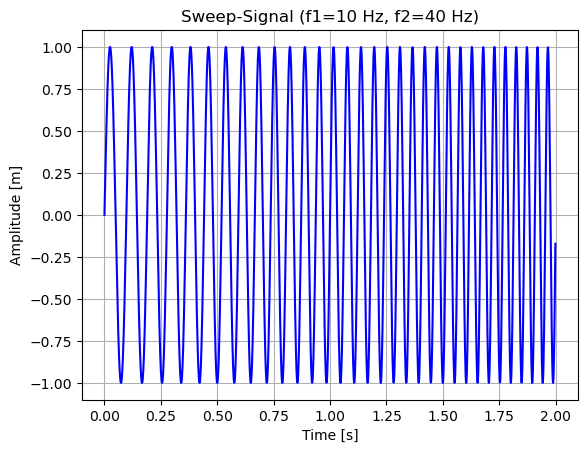

In [4]:
# Define sweep with small bandwidth
# ---------------------------------
f1 = 10.0                             # minimum sweep frequency f1
f2 = 40.0                             # maximum sweep frequency f2
T = 10.0                              # sweep length [s]
time, sweep1 = create_sweep(f1,f2,T)  # Create sweep signal

# Plot sweep signal with small bandwidth
draw_func1(time[0:nt_max],sweep1[0:nt_max],'Sweep-Signal (f1=10 Hz, f2=40 Hz)', 'Time [s]', 'Amplitude [m]')

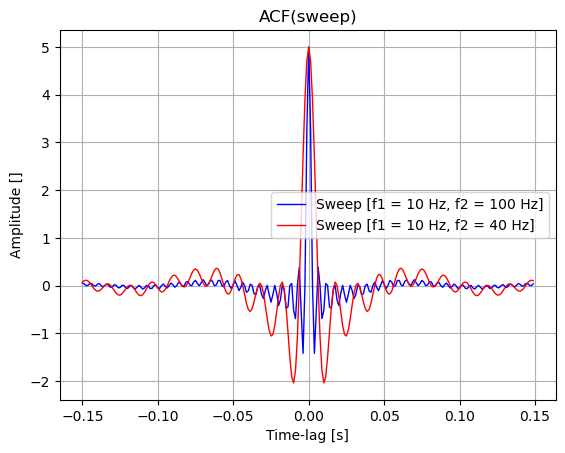

In [5]:
# ACF of sweep signal with small bandwidth
AKF_sweep1 = np.correlate(sweep1, sweep1, mode='same')

# Multiply AKF_sweep with dt to get correct amplitudes
AKF_sweep1 = AKF_sweep1 * dt

# Plot ACF with different bandwidth
comp_AKF_sweep1(lags[nt1:nt2],AKF_sweep[nt1:nt2],AKF_sweep1[nt1:nt2],'ACF(sweep)','Time-lag [s]', 'Amplitude []')

## Synthetic data example

To illustrate the concept of the vibroseismic method, we will generate a synthetic dataset. For a 1D medium, the **spike response** or **Greens’ functions** of the subsurface model can be calculated using simple travel time calculations and transmission and reflection coefficients (see Seismic lecture). 

Let us consider the following spike response for two layers above a half-space model

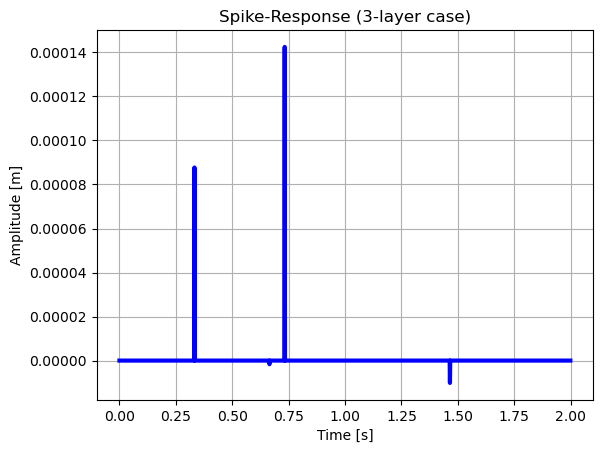

In [6]:
# Create Spike Response
green = create_spike_3_layers(time)

# Plot Spike Response
draw_func(time[0:nt_max],green[0:nt_max],'Spike-Response (3-layer case)', 'Time [s]', 'Amplitude [m]')

The spike response shows two positive spikes, which correspond to the primary reflections from the first and second layer boundaries respectively. The negative spikes are the associated multiple reflections. The convolution of the spike response $R$ with the vibroseismic signal $S$ yields the synthetic vibroseismogram $x_{vib}$, in accordance with the **representation theorem**:

$$  x_{vib} = S * R$$

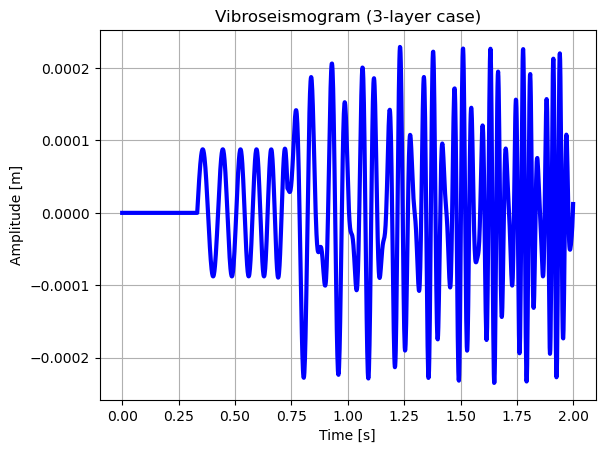

In [7]:
# Convolution of the source signal with the spike response
xvib = np.convolve(sweep,green) 
nt = (int)(len(time))
xvib = xvib[0:nt]

# Plot spike response
draw_func(time[0:nt_max],xvib[0:nt_max],'Vibroseismogram (3-layer case)', 'Time [s]', 'Amplitude [m]')

No reflection segments can be identified in the vibroseismogram. To extract these reflection signals, we calculate the CCF of the vibroseismogram using the sweep ...

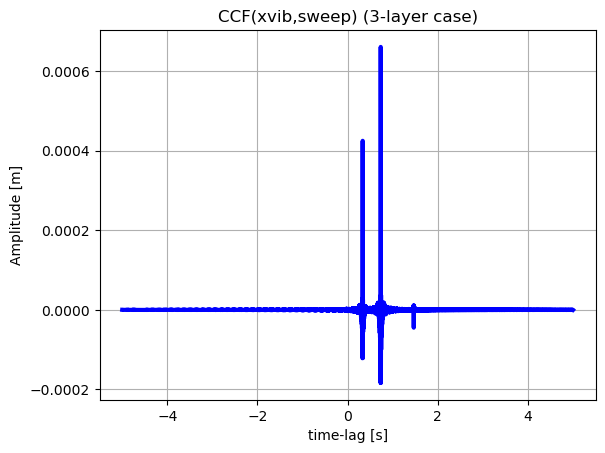

In [8]:
# CCF of vibroseismogram and sweep
KKF_sweep_vibro = np.correlate(xvib,sweep, mode='same') * dt

# Plot CCF of vibroseismogram and sweep
draw_func(lags,KKF_sweep_vibro,'CCF(xvib,sweep) (3-layer case)', 'time-lag [s]', 'Amplitude [m]')

Where there are positive time lags, a number of correlations can be observed. Let’s take a closer look at these and compare them with the spike response:

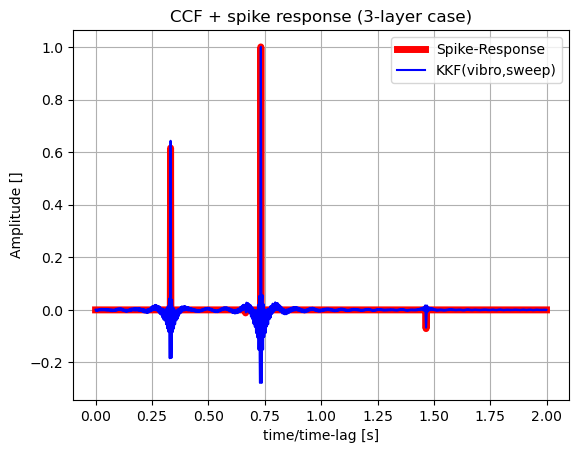

In [9]:
# Plot CCF of vibroseismograms with sweep for positive time-lags up to 2 s
nth = (int)(nt/2)
draw_func2(lags[nth:nth+nt_max],KKF_sweep_vibro[nth:nth+nt_max],green[0:nt_max],'CCF + spike response (3-layer case)', 'time/time-lag [s]', 'Amplitude []')

The (multiple) reflection arrival times in the spike response coincide with pronounced local maxima and minima in the CCF between the vibroseismogram and the sweep at the corresponding time-lags. The waveform of the reflection insets corresponds to the ACF of the sweep.  

But how robust is the method against noise? Let us add some noise to the vibroseismogram, correlate it again with the sweep and compare the result once more with the spike response:

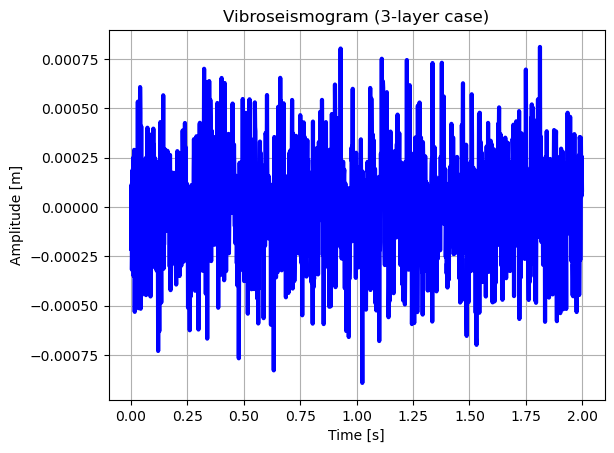

In [10]:
# Create normal distributed noise 
noise_amp = 1.
noise = np.random.normal(0,noise_amp,len(time))

# Add noise to vibroseismogram
xvib_noise = xvib + noise * np.amax(xvib)

# Plot vibroseismogram with noise
draw_func(time[0:nt_max],xvib_noise[0:nt_max],'Vibroseismogram (3-layer case)', 'Time [s]', 'Amplitude [m]')

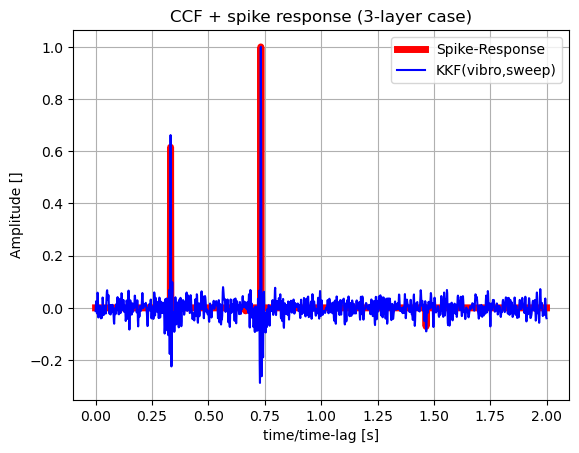

In [11]:
# CCF of vibroseismogram and sweep
KKF_sweep_vibro_noise = np.correlate(xvib_noise,sweep, mode='same') * dt

# Plot CCF of noisy vibroseismogram with sweep for positive time-lags up to 2 s
nth = (int)(nt/2)
draw_func2(lags[nth:nth+nt_max],KKF_sweep_vibro_noise[nth:nth+nt_max],green[0:nt_max],'CCF + spike response (3-layer case)', 'time/time-lag [s]', 'Amplitude []')

Even with much noisier data, the CCF of the vibroseismogram with the sweep still shows clear peaks at the arrival times of the dominant reflections. Let’s see how well vibroseismic data works for a field data application.

## Field data example: Surendorf

As part of the [ANGUS-II project](http://www.angus2.de/de), active seismic data were recorded in early May 2019 in Surendorf, south of Eckernförde Bay in Schleswig-Holstein, using a vibrosismic source and a drop weight.

<img src="images/surendorf_overview.jpg" style="width: 800px;"/>

The aim was to map potential deep fault zones that had been identified during earlier marine and land-based seismic surveys using conventional seismic processing [(Al Hseinat et al. 2016)](https://www.researchgate.net/publication/302231461_Triassic_to_recent_tectonic_evolution_of_a_crestal_collapse_graben_above_a_salt-cored_anticline_in_the_Gluckstadt_GrabenNorth_German_Basin). The new datasets are specifically designed to enable the derivation of high-resolution models of the distribution of elastic material parameters in the subsurface using full-waveform inversion (FWI).

As an example, let us import the sweep signal, band-pass filtered from 10 to 80 Hz, as well as the vibroseismogram from channel 68 (shot 50):

In [12]:
# Import sweep ...
sweep = np.loadtxt('data/surendorf/sweep_10_80_le.txt', delimiter='\t', skiprows=0, unpack='False')

# ... and vibroseismogram
vibroseis = np.loadtxt('data/surendorf/raw50_traf68_le.txt', delimiter='\t', skiprows=0, unpack='False')

# Definie sample interval dt = 1 ms
dt = 0.001

# Estimate length of time series
print("nt_sweep = ",len(sweep))
print("nt_vibroseis = ",len(vibroseis))

nt_sweep =  10001
nt_vibroseis =  15120


As you can see, the sweep and the vibroseismogram are of different lengths, so the first thing we do is zero-pad the shorter sweep signal:

In [13]:
# Initialize new sweep vector
sweep_new = np.zeros(len(vibroseis))

# Copy old sweep vector in new sweep vector
sweep_new[0:len(sweep)] = sweep[0:len(sweep)]

# Estimate length of new sweep
print("nt_sweep_new = ",len(sweep_new))

nt_sweep_new =  15120


The time vector can be estimated from the sample interval $dt$ and the number of samples $nt$:

In [14]:
# Define time vector
nt = (int)(len(sweep_new))
time1 = np.arange(0,nt*dt,dt)

Therefore, we get the following sweep signal ...

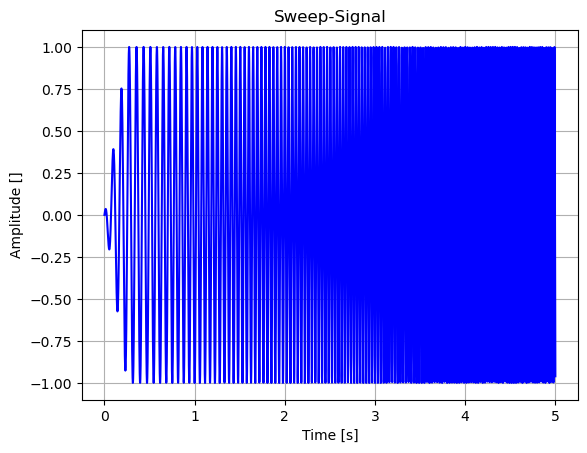

In [15]:
# Plot sweep signal
draw_func1(time1[0:5000],sweep_new[0:5000],'Sweep-Signal', 'Time [s]', 'Amplitude []')

... the spectrum covers frequencies from 10 - 80 Hz ...

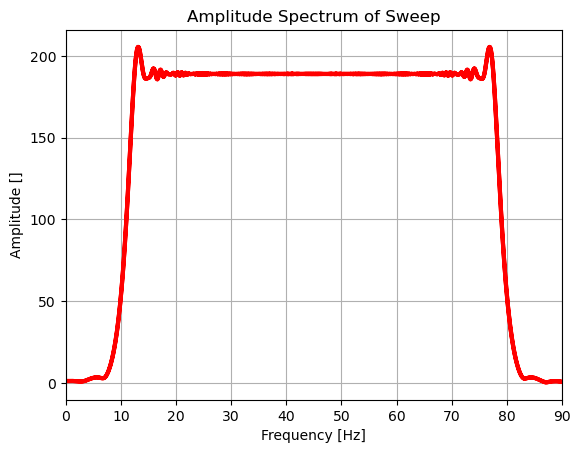

In [16]:
# Plot amplitude spectrum
fmax = 90.   # maximum frequency
plot_spec(time1,sweep_new,fmax,'Amplitude Spectrum of Sweep','Frequency [Hz]','Amplitude []')

The ACF of the sweep signal leads to

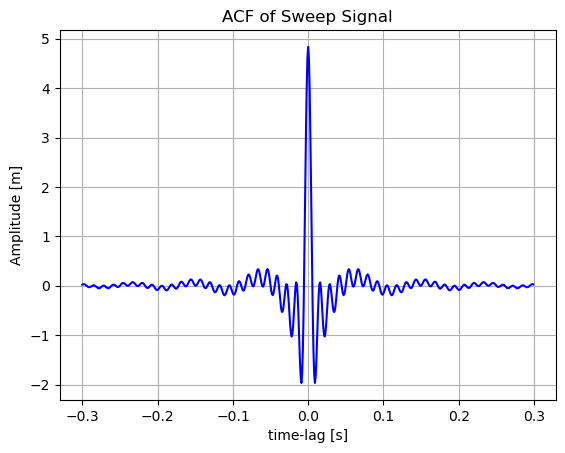

In [17]:
# ACF of sweep signal
AKF_sweep_new = np.correlate(sweep_new, sweep_new, mode='same')

# Multiply CCF_sweep with dt to get correct amplitudes
dt = time1[1] - time1[0]
AKF_sweep_new = AKF_sweep_new * dt

# Compute time-lags
nt = (int)(len(time1))
lags = np.arange(-nt/2,nt/2,1) * dt # time-lags

# Plot ACF of sweep
wnt = 300
nth = (int)(nt/2)
draw_func1(lags[nth-wnt:nth+wnt],AKF_sweep_new[nth-wnt:nth+wnt],'ACF of Sweep Signal', 'time-lag [s]', 'Amplitude [m]')

The vibroseismogram shows different seismic phases ...

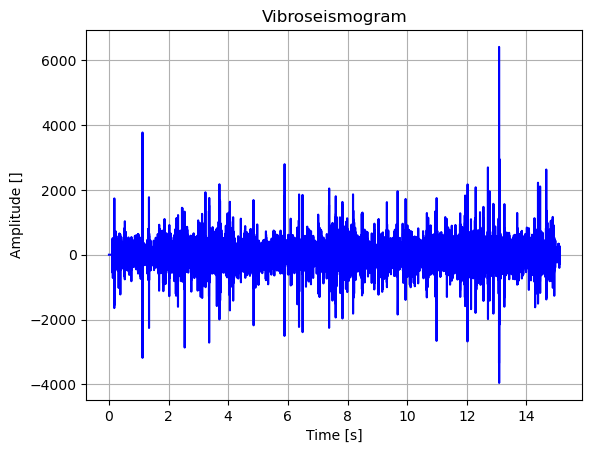

In [18]:
# Plot vibroseismogram
draw_func1(time1,vibroseis,'Vibroseismogram', 'Time [s]', 'Amplitude []')

Finally, we correlate the sweep with the vibroseismogram using the NumPy function `correlate`

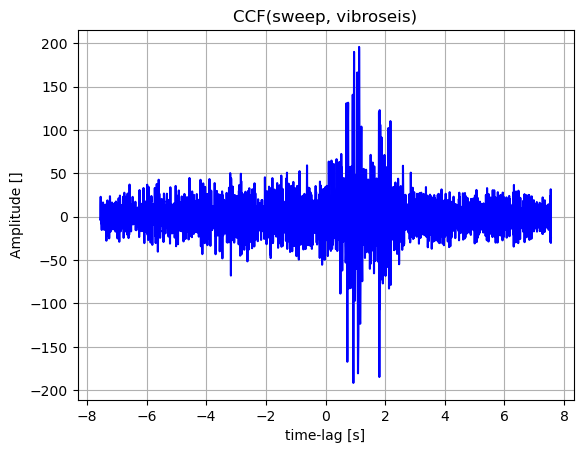

In [19]:
# CCF  of sweep with vibroseismogram
KKF_sweep = np.correlate(sweep, vibroseis, mode='same')

# Multiply CCF with dt to get correct amplitudes
KKF_sweep = KKF_sweep * dt

# Compute time-lags
lags = np.arange(-nt/2,nt/2,1) * dt # time-lags

# Plot CCF of sweep with vibroseismogram
draw_func1(lags,KKF_sweep,'CCF(sweep, vibroseis)', 'time-lag [s]', 'Amplitude []')

Notice the strong correlation at positive time-lags. Let 's take a closer look ...

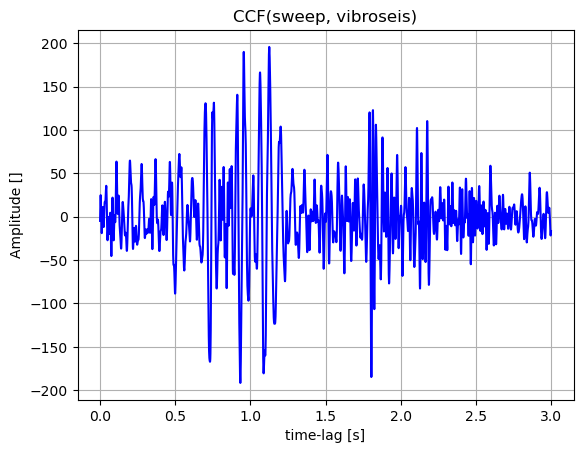

In [20]:
# Plot CCF of sweep with vibroseismogram for positive time-lags
nt1 = 3000
nth = (int)(nt/2)
draw_func1(lags[nth:nth+nt1],KKF_sweep[nth:nth+nt1],'CCF(sweep, vibroseis)', 'time-lag [s]', 'Amplitude []')

The first arrival is located at 0.36 s, some reflections are visible between 0.4 - 1.2 s. Finally, surface waves occur at about 1.4 s. Compared to the synthetic example, the sweep correlates to some extent with noise. Therefore, the reflections and first arrival are not easy to identify.